# 01 Data Audit

Thin review notebook for artifacts produced by `make validate-data` and `make build-cohort`. This notebook inspects saved outputs only; it does not construct cohorts, define causal variables, or run estimators.

In [1]:
from pathlib import Path
import json
import sys

from IPython.display import Image, display
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from oulad_causal.config import FIGURES_DIR, METADATA_DIR, PROCESSED_DATA_DIR

metadata_dir = METADATA_DIR
processed_dir = PROCESSED_DATA_DIR
figures_dir = FIGURES_DIR
metadata_dir, processed_dir, figures_dir

(PosixPath('/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/metadata'),
 PosixPath('/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed'),
 PosixPath('/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/reports/figures'))

## Raw Validation Artifacts

In [2]:
table_shapes = pd.read_csv(metadata_dir / "table_shapes.csv")
schema = pd.read_csv(metadata_dir / "schema_validation.csv")
duplicates = pd.read_csv(metadata_dir / "duplicate_key_summary.csv")
missingness = pd.read_csv(metadata_dir / "missingness_summary.csv")
dates = pd.read_csv(metadata_dir / "date_range_summary.csv")
categories = pd.read_csv(metadata_dir / "category_frequency_summary.csv")

table_shapes

,table_name,loaded,row_count,column_count,expected_column_count
0,courses,True,22,3,3
1,assessments,True,206,6,6
2,vle,True,6364,6,6
3,studentInfo,True,32593,12,12
4,studentRegistration,True,32593,5,5
5,studentAssessment,True,173912,5,5
6,studentVle,True,10655280,6,6


In [3]:
schema[["table_name", "missing_columns", "extra_columns", "column_order_matches", "is_valid"]]

,table_name,missing_columns,extra_columns,column_order_matches,is_valid
0,courses,NaN,NaN,True,True
1,assessments,NaN,NaN,True,True
2,vle,NaN,NaN,True,True
3,studentInfo,NaN,NaN,True,True
4,studentRegistration,NaN,NaN,True,True
5,studentAssessment,NaN,NaN,True,True
6,studentVle,NaN,NaN,True,True


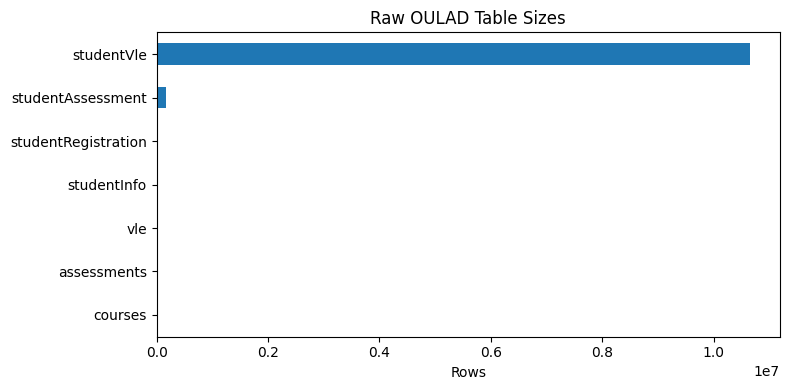

In [4]:
ax = table_shapes.sort_values("row_count").plot.barh(x="table_name", y="row_count", legend=False, figsize=(8, 4))
ax.set_xlabel("Rows")
ax.set_ylabel("")
ax.set_title("Raw OULAD Table Sizes")
plt.tight_layout()

In [5]:
missingness.sort_values("missing_fraction", ascending=False).head(20)

,table_name,column,dtype,row_count,missing_count,nonmissing_count,missing_fraction
14,vle,week_to,float64,6364,5243,1121,0.823853
13,vle,week_from,float64,6364,5243,1121,0.823853
31,studentRegistration,date_unregistration,float64,32593,22521,10072,0.690977
7,assessments,date,float64,206,11,195,0.053398
21,studentInfo,imd_band,str,32593,1111,31482,0.034087
30,studentRegistration,date_registration,float64,32593,45,32548,0.001381
36,studentAssessment,score,float64,173912,173,173739,0.000995
2,courses,module_presentation_length,int64,22,0,22,0.000000
3,assessments,code_module,str,206,0,206,0.000000
1,courses,code_presentation,str,22,0,22,0.000000


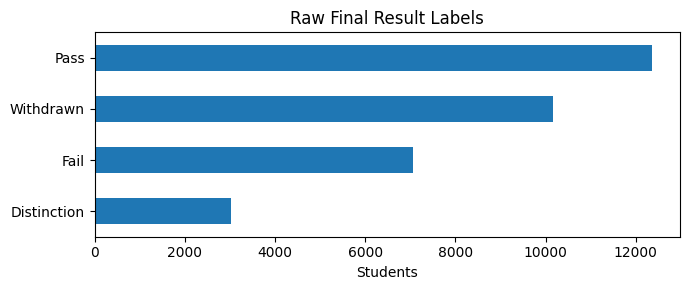

In [6]:
final_result = categories[(categories["table_name"] == "studentInfo") & (categories["column"] == "final_result")]
ax = final_result.sort_values("count").plot.barh(x="category", y="count", legend=False, figsize=(7, 3))
ax.set_xlabel("Students")
ax.set_ylabel("")
ax.set_title("Raw Final Result Labels")
plt.tight_layout()

In [7]:
dates

,table_name,column,row_count,missing_count,nonnumeric_count,min,max,below_warning_min_count,above_warning_max_count,after_max_module_length_count,warning
0,assessments,date,206,11,0,12.0,261.0,0,0,0,NaN
1,studentRegistration,date_registration,32593,45,0,-322.0,167.0,0,0,0,NaN
2,studentRegistration,date_unregistration,32593,22521,0,-365.0,444.0,0,0,1,1 values after the maximum module length
3,studentAssessment,date_submitted,173912,0,0,-11.0,608.0,0,0,73,73 values after the maximum module length
4,studentVle,date,10655280,0,0,-25.0,269.0,0,0,0,NaN


## Analytic Cohort Artifacts

In [8]:
cohort_path = processed_dir / "oulad_analytic_cohort.parquet"
flow_path = processed_dir / "cohort_flow_table.csv"
summary_path = processed_dir / "cohort_summary.json"

cohort = pd.read_parquet(cohort_path)
cohort_flow = pd.read_csv(flow_path)
cohort_summary = json.loads(summary_path.read_text())

cohort.shape, cohort_summary["cohort_size"]

((28128, 65), 28128)

In [9]:
cohort_flow

,stage,row_count,excluded_count,description
0,student_info_records,32593,0,studentInfo records loaded.
1,after_required_table_joins,32593,0,Dropped records without registration or course...
2,after_primary_treatment_eligibility,28128,4465,Dropped records with date_unregistration < 14;...


In [10]:
primary_treatment_columns = [
    "treatment_high_engagement_14d_median",
    "treatment_high_engagement_14d_top_tertile",
    "treatment_high_engagement_14d_top_quartile",
]
pd.DataFrame(
    [
        {
            "treatment": column,
            "nonmissing": int(cohort[column].notna().sum()),
            "treated": int(cohort[column].sum()),
            "prevalence": float(cohort[column].mean()),
        }
        for column in primary_treatment_columns
    ]
)

,treatment,nonmissing,treated,prevalence
0,treatment_high_engagement_14d_median,28128,14134,0.502489
1,treatment_high_engagement_14d_top_tertile,28128,9429,0.335218
2,treatment_high_engagement_14d_top_quartile,28128,7080,0.251706


In [11]:
cohort[[
    "code_module",
    "code_presentation",
    "id_student",
    "final_result",
    "outcome_success",
    "early_clicks_14d",
    "early_clicks_14d_z",
    "treatment_high_engagement_14d_median",
]].head()

,code_module,code_presentation,id_student,final_result,outcome_success,early_clicks_14d,early_clicks_14d_z,treatment_high_engagement_14d_median
0,AAA,2013J,11391,Pass,1,203.0,0.053565,1
1,AAA,2013J,28400,Pass,1,241.0,0.249576,1
2,AAA,2013J,31604,Pass,1,176.0,-0.085706,1
3,AAA,2013J,32885,Pass,1,177.0,-0.080548,1
4,AAA,2013J,38053,Pass,1,276.0,0.430112,1


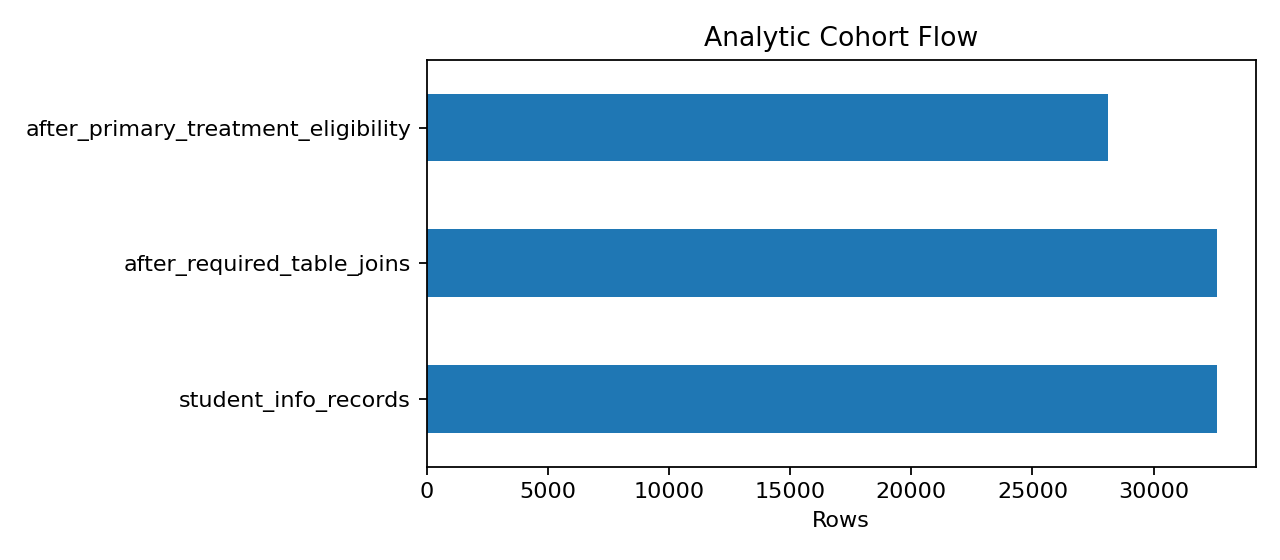

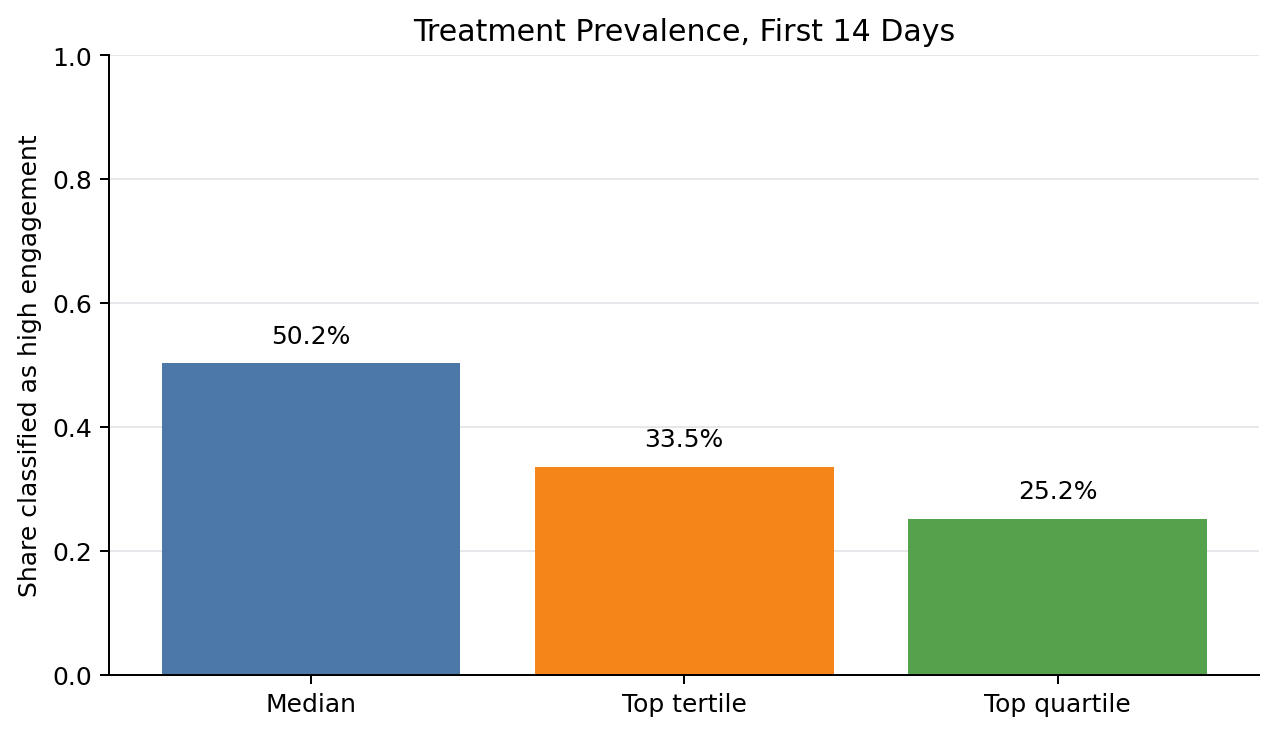

In [12]:
for figure_name in ["cohort_flow.png", "treatment_prevalence.png"]:
    display(Image(filename=str(figures_dir / figure_name)))